# Comparing UOT methods
UOT does seem to change when reg_m increases, but general trends seem roughly the same. To assess these trends, we'll compare the three methods we tested to see how reg_m correlates to changes in the data.

## Imports

In [20]:
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool, fetch_region, get_cool_name, hic_ot, hic_ot_bulk

# Setting data directory
sc_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'
save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_uot_clustering/OT'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Helper Functions

In [2]:
def map_cell_types(data: pd.DataFrame, cell_type_map: pd.DataFrame):
    '''
        Transforms file name to file name comparisons in a pandas dataframe
        to a long format where each comparison has its own row, specifying inter
        or intra cell type of interest interactions.

        This function assusming formatting used in this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            File name to file name dataframe of comparisons (SCC or OT).
        cell_type_map : pd.DataFrame
            Dataframe mapping file names to cell types.

        Returns
        -------
        data_long : pd.DataFrame
            A long format version of data with cell type information.
    '''

    # Mapping file to type
    type_lookup = cell_type_map.set_index("cell_name")["cell_type"]

    # Long format
    data_long = data.reset_index().rename(columns={"index": "row_file"})
    data_long = data_long.melt(id_vars="row_file",
                        var_name="col_file",
                        value_name="value")
    # Mapping celltypes
    data_long["row_cell_type"] = data_long["row_file"].map(type_lookup)
    data_long["col_cell_type"] = data_long["col_file"].map(type_lookup)

    # Inter and intra
    data_long["relationship"] = (
        data_long["row_cell_type"] == data_long["col_cell_type"]
        ).map({True: "intra", False: "inter"})

    return data_long

def load_ot_results_long(folder: str, res: int, thres: int, cell_count: int, gamma: float = None, reg_m : float|None = None):
    '''
        Loads all csv files corresponding to OT results
        in the given folder.

        This function is very specific to this notebook.

        Parameters
        ----------
        folder : str
            Path to folder that is to be imported.
        res : int
            Resolution used for analysis.
        thres : int
            Threshold used for analysis.
        cell_count : int
            Number of cells used for analysis.
        gamma : float
            Distance scaling parameter.
            Default = None, looks for unscaled data.
        reg_m : float
            Unbalanced parameter used.
            Default = None, looks for balanced data.
        
        Returns
        -------
        ot_df_long : pd.Dataframe
            Long form dataframe with combined data from all
            OT results.
    '''
    folder = Path(folder)
    
    # Storage dictonary
    ot_dfs = []

    # Regex patterns
    cc = re.escape(str(cell_count))

    #if gamma is None:
    #    pattern = re.compile(
    #        rf"^(.*?)_type_clustering_ot_{res}mb_{thres}_{cell_count}\.csv$"
    #    )
    #else:
    
    if reg_m is None:
        pattern = re.compile(
            rf"^balanced_(.*?)_cluster_{res}mb_{thres}_{cell_count}_γ={gamma}\.csv$"
        )
    else:
        pattern = re.compile(
            rf"^unbalanced_reg_m={reg_m}_(.*?)_cluster_{res}mb_{thres}_{cell_count}_γ={gamma}\.csv$"
        )

    for file in folder.glob("*.csv"):
        name = file.name

        m = pattern.match(name)
        if m:
            df = pd.read_csv(file, index_col=0)
            ot_dfs.append(df)

    # Covert to long and concatenate
    metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
    ot_dfs_long = []
    for df in ot_dfs:
        ot_dfs_long.append(map_cell_types(df, metadata))
    
    ot_df_long = pd.concat(ot_dfs_long)

    return ot_df_long

def distribution_plot(data: pd.DataFrame, ax, reg_m: float|None=None, value : str="value"):
    '''
        Plots the distribution of the provided dataframe to
        the provided Axes object.

        Function is very specific to this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            Data to be plotted.
        ax
            Axes object to plot to.
        reg_m : float
            Unbalanced parameter used.
            Default = None, used balanced OT.
        value : str
            Type of value to visualize
            Default = "value"
    '''
    # Setting order
    order = ["inter", "intra"]

    # Stripplot
    sns.stripplot(
    data=data,
    x="relationship",
    y=value,
    order=order,
    hue="relationship",
    dodge=False,
    jitter=True,
    alpha=0.05,
    palette={
        "inter": "#1f77b4",
        "intra": "#ff7f0e"
    },
    ax=ax
    )

    # Violin plot
    sns.violinplot(
        data=data,
        x="relationship",
        y=value,
        order=order,
        inner=None,
        color="lightgray",
        cut=0,
        ax=ax
    )

    ax.set_ylim(bottom=0)
    ax.set_ylabel("OT Loss")
    if reg_m is None:
        ax.set_title("Balanced OT")
    else:
        ax.set_title(f"UOT (reg_m={reg_m})")
    return

## Importing and Visualizing Raw Data

In [3]:
### Importing ###
uot_data = {}
uot_data[0.1] = load_ot_results_long(save_dir, 1, 95, 20, reg_m=0.1)
uot_data[1] = load_ot_results_long(save_dir, 1, 95, 20, reg_m=1)
uot_data[10] = load_ot_results_long(save_dir, 1, 95, 20, reg_m=10)

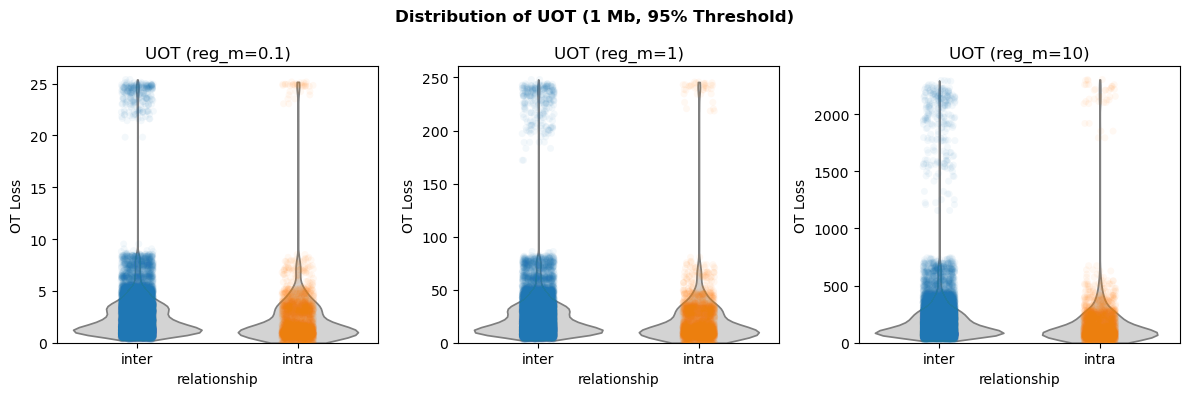

In [4]:
### Violin Plots ###
    # Initializing figure
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
axes = ax.flatten()

    # Adding subpanels
for i, (reg_m, data) in enumerate(uot_data.items()):
    distribution_plot(data, axes[i], reg_m)

    # Adding titles
plt.suptitle("Distribution of UOT (1 Mb, 95% Threshold)", fontweight="bold")
plt.tight_layout()

## Log Transforming and Visualizing
Should make data more uniform and thus easier to compare.

In [5]:
### Log Transforming ###
for (reg_m, data) in uot_data.items():
    data["log_value"] = np.log(data["value"] + 1)
    uot_data[reg_m] = data

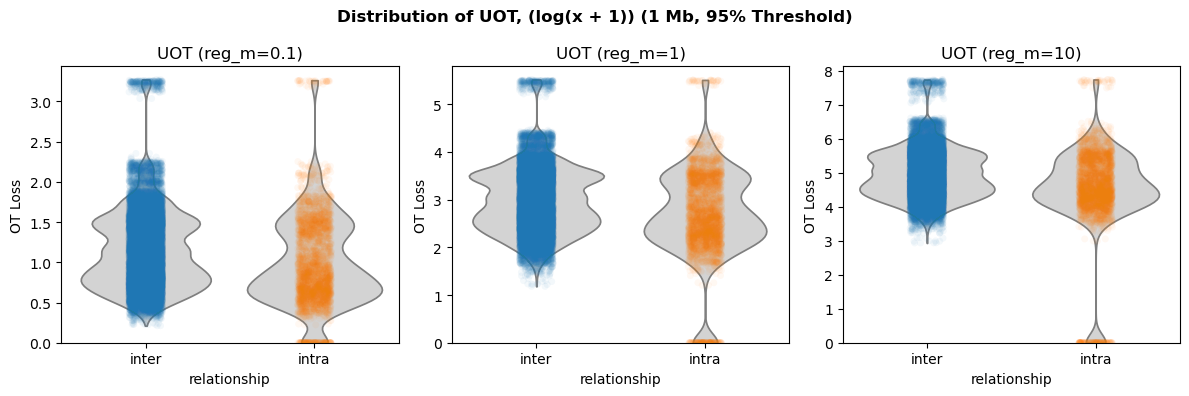

In [6]:
### Violin Plots ###
    # Initializing figure
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
axes = ax.flatten()

    # Adding subpanels
for i, (reg_m, data) in enumerate(uot_data.items()):
    distribution_plot(data, axes[i], reg_m, value="log_value")

    # Adding titles
plt.suptitle("Distribution of UOT, (log(x + 1)) (1 Mb, 95% Threshold)", fontweight="bold")
plt.tight_layout()

## Dividing by Median and Visualizing
If the data distributions are indeed identical, dividing by the median should show near identical distributions

In [7]:
### Dividing by the median ###
### Log Transforming ###
for (reg_m, data) in uot_data.items():
    data["log_value_max"] = data["log_value"] / np.max(data["log_value"])
    uot_data[reg_m] = data

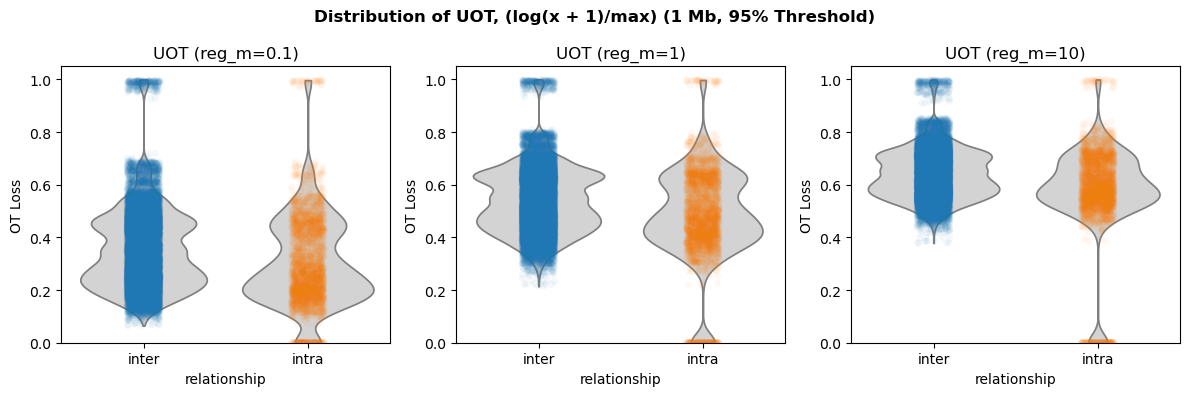

In [8]:
### Violin Plots ###
    # Initializing figure
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
axes = ax.flatten()

    # Adding subpanels
for i, (reg_m, data) in enumerate(uot_data.items()):
    distribution_plot(data, axes[i], reg_m, value="log_value_max")

    # Adding titles
plt.suptitle("Distribution of UOT, (log(x + 1)/max) (1 Mb, 95% Threshold)", fontweight="bold")
plt.tight_layout()